# Decision Trees and Random Forests


## Outline

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tools4ds/DS701-Materials-FA26/blob/main/jupyter_notebooks/08-Classification-I-Decision-Trees.ipynb)

- Build a decision tree manually
- Look at single and collective impurity measures
- Selecting splitting attributes and test conditions
- Scikit-learn implementation
- Model training and evaluation
- Bias and Variance
- Random forests

## Introduction

In [1]:
#| echo: false
from sklearn import tree

We'll now start looking into how to build models to predict an outcome variable from labeled data.

**Classification** problems:

- predict a category
- e.g., spam/not spam, fraud/not fraud, default/not default, malignant/benign, etc.

**Regression** problems:

- predict a numeric value
- e.g., price of a house, salary of a person, etc.


# Loan Default Example

We'll use an example from [@Tan2018].

![](figs/L14-terrier-savings-logo.png)

You are a loan officer at **Terrier Savings and Loan**. 

You have a dataset on loans that you have made in the past.

You want to build a model to predict whether a loan will default.

## Loans Data Set

In [2]:
#| echo: true
import pandas as pd

import os
import urllib.request

# Check if the directory exists, if not, create it
if not os.path.exists('data'):
    os.makedirs('data')

if not os.path.exists('data/loans.csv'):
    url = 'https://tools4ds.github.io/ds701/data/loans.csv'
    urllib.request.urlretrieve(url, 'data/loans.csv')

loans = pd.read_csv('data/loans.csv', index_col=0)
loans

,Home Owner,Marital Status,Annual Income,Defaulted Borrower
ID,,,,
1,Yes,Single,125000,No
2,No,Married,100000,No
3,No,Single,70000,No
4,Yes,Married,120000,No
5,No,Divorced,95000,Yes
6,No,Married,60000,No
7,Yes,Divorced,220000,No
8,No,Single,85000,Yes
9,No,Married,75000,No


## Loans Data Set Summary

Here's the summary info of the data set.

In [3]:
loans.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 1 to 10
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Home Owner          10 non-null     str  
 1   Marital Status      10 non-null     str  
 2   Annual Income       10 non-null     int64
 3   Defaulted Borrower  10 non-null     str  
dtypes: int64(1), str(3)
memory usage: 452.0 bytes


## Convert to Categorical Data Types

Since some of the fields are categorical, let's convert them to categorical data types.

In [4]:
#| code-fold: false
loans['Home Owner'] = loans['Home Owner'].astype('category')
loans['Marital Status'] = loans['Marital Status'].astype('category')
loans['Defaulted Borrower'] = loans['Defaulted Borrower'].astype('category')
loans.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 1 to 10
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Home Owner          10 non-null     category
 1   Marital Status      10 non-null     category
 2   Annual Income       10 non-null     int64   
 3   Defaulted Borrower  10 non-null     category
dtypes: category(3), int64(1)
memory usage: 298.0 bytes


## Simple Model

Looking at the table, let's just start with the simplest model possible and just
predict that no one will default.

So the output of our model is just to always predict "No".

In [7]:
import os

os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

import shutil
print(shutil.which("dot"))

C:\Program Files\Graphviz\bin\dot.EXE


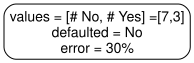

In [8]:
#| echo: false
#| fig-align: center
import graphviz

dot_data = """
digraph Tree {
    node [shape=box, style="filled, rounded", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="values = [# No, # Yes] =[7,3]\\ndefaulted = No\\nerror = 30%", fillcolor="#ffffff"] ;
}
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

<!-- TODO: Look at this reference to consider pydotplus for size control -->


We see a 30% error rate since 3 out of 10 loans defaulted.

---

Let's split the data based on the "Home Owner" field. (`values = [# No, # Yes]`).

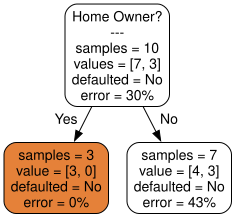

In [9]:
#| echo: false
#| fig-align: center
import graphviz

dot_data = """
digraph Tree {
    node [shape=box, style="filled, rounded", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Home Owner?\\n---\\nsamples = 10\\nvalues = [7, 3]\\ndefaulted = No\\nerror = 30%", fillcolor="#ffffff"] ;
    1 [label="samples = 3\\nvalue = [3, 0]\\ndefaulted = No\\nerror = 0%", fillcolor="#e58139"] ;
    2 [label="samples = 7\\nvalue = [4, 3]\\ndefaulted = No\\nerror = 43%", fillcolor="#ffffff"] ;
    0 -> 1 [labeldistance=2.5, labelangle=45, headlabel="Yes"] ;
    0 -> 2 [labeldistance=2.5, labelangle=-45, headlabel="No"] ;}
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

We see that the left node (`Home Owner == Yes`) has a 0% error rate since all the samples are `Defaulted == No`. We don't split this node since all the samples are of the same class. We call this node a **leaf node** and we'll color it orange.


The right node (`Home Owner == No`) has a 43% error rate since 3 out of 7 loans defaulted. 

Let's split this node into two nodes based on the **Marital Status** field.

---

Let's split on the "Marital Status" field.

We see that the 3 defaulted loans are all for single or divorced people. Since the node is
all one class, we don't split this node and we call it a **leaf node**.

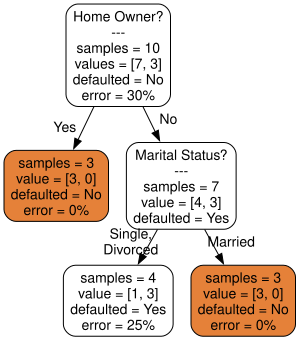

In [10]:
#| echo: false
#| fig-align: center
import graphviz

dot_data = """
digraph Tree {
    node [shape=box, style="filled, rounded", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Home Owner?\\n---\\nsamples = 10\\nvalues = [7, 3]\\ndefaulted = No\\nerror = 30%", fillcolor="#ffffff"] ;
    1 [label="samples = 3\\nvalue = [3, 0]\\ndefaulted = No\\nerror = 0%", fillcolor="#e58139"] ;
    2 [label="Marital Status?\\n---\\nsamples = 7\\nvalue = [4, 3]\\ndefaulted = Yes", fillcolor="#ffffff"] ;
    3 [label="samples = 4\\nvalue = [1, 3]\\ndefaulted = Yes\\nerror = 25%", fillcolor="#ffffff"] ;
    4 [label="samples = 3\\nvalue = [3, 0]\\ndefaulted = No\\nerror = 0%", fillcolor="#e58139"] ;
    0 -> 1 [labeldistance=2.5, labelangle=45, headlabel="Yes"] ;
    0 -> 2 [labeldistance=2.5, labelangle=-45, headlabel="No"] ;
    2 -> 3 [labeldistance=2.5, labelangle=45, headlabel="Single,\\nDivorced"] ;
    2 -> 4 [labeldistance=2.5, labelangle=-45, headlabel="Married"] ;}
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

--- 

We can list the subsets for the two criteria to calculate the error rate.

In [11]:
#| fig-cap: 'Table: Home Owner == No and Marital Status == Single or Divorced --> Defaulted == Yes'
#| fig-cap-location: top
loans[(loans['Home Owner'] == "No") & (loans['Marital Status'].isin(['Single', 'Divorced']))]

,Home Owner,Marital Status,Annual Income,Defaulted Borrower
ID,,,,
3,No,Single,70000,No
5,No,Divorced,95000,Yes
8,No,Single,85000,Yes
10,No,Single,90000,Yes


Error rate for predicting `Defaulted == Yes` is 25%.


---

and...

In [12]:
#| fig-cap: 'Table: Home Owner == No and Marital Status == Married --> Defaulted == No'
#| fig-cap-location: top
loans[(loans['Home Owner'] == "No") & (loans['Marital Status'] == "Married")]

,Home Owner,Marital Status,Annual Income,Defaulted Borrower
ID,,,,
2,No,Married,100000,No
6,No,Married,60000,No
9,No,Married,75000,No


Error rate for predicting `Defaulted == No` is 0%.


---


* Let's try to split on the "Annual Income" field. 

* We see that the person with income of 70K doesn't default, so we split the node into two nodes based on the "Income" field. 

* We arbitrarily pick a threshold of $75K.


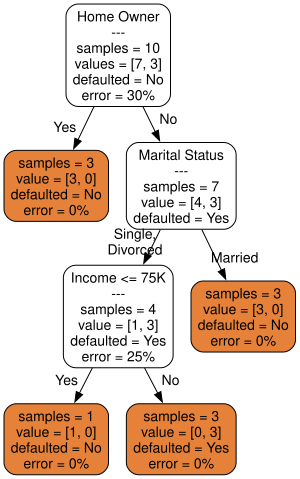

In [13]:
#| echo: false
#| fig-align: center
import graphviz

dot_data = """
digraph Tree {
    graph [size="8,8"];
    node [shape=box, style="filled, rounded", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Home Owner\\n---\\nsamples = 10\\nvalues = [7, 3]\\ndefaulted = No\\nerror = 30%", fillcolor="#ffffff"] ;
    1 [label="samples = 3\\nvalue = [3, 0]\\ndefaulted = No\\nerror = 0%", fillcolor="#e58139"] ;
    2 [label="Marital Status\\n---\\nsamples = 7\\nvalue = [4, 3]\\ndefaulted = Yes", fillcolor="#ffffff"] ;
    3 [label="Income <= 75K\\n---\\nsamples = 4\\nvalue = [1, 3]\\ndefaulted = Yes\\nerror = 25%", fillcolor="#ffffff"] ;
    4 [label="samples = 3\\nvalue = [3, 0]\\ndefaulted = No\\nerror = 0%", fillcolor="#e58139"] ;
    5 [label="samples = 1\\nvalue = [1, 0]\\ndefaulted = No\\nerror = 0%", fillcolor="#e58139"] ;
    6 [label="samples = 3\\nvalue = [0, 3]\\ndefaulted = Yes\\nerror = 0%", fillcolor="#e58139"] ;
    0 -> 1 [labeldistance=2.5, labelangle=45, headlabel="Yes"] ;
    0 -> 2 [labeldistance=2.5, labelangle=-45, headlabel="No"] ;
    2 -> 3 [labeldistance=2.5, labelangle=45, headlabel="Single,\\nDivorced"] ;
    2 -> 4 [labeldistance=2.5, labelangle=-45, headlabel="Married"] ;
    3 -> 5 [labeldistance=2.5, labelangle=45, headlabel="Yes"] ;
    3 -> 6 [labeldistance=2.5, labelangle=-45, headlabel="No"] ;}
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)
graph

# Evaluating the Model

## Evaluating the Model

* We've dispositioned every data point by walking down the tree to a leaf node.

* How do we know if this tree is good? 

    * We arbitrarily picked the order of the fields to split on.

* Is there a way to systematically pick the order of the fields to split on? 

    * This is called the **splitting criterion**.

* There's also the question of when to stop splitting, or the **stopping criterion**. 

* So far, we stopped splitting when we reached a node of pure class but there are 
reasons to stop splitting even without pure classes, which we'll see later.


## Specifying the Test Condition

Before we continue, we should take a moment to consider how we specify a test condition of a node.

How we specify a test condition depends on the attribute type which can be:

* Binary (Boolean)
* Nominal (Categorical, e.g., cat, dog, bird)
* Ordinal (e.g., Small, Medium, Large)
* Continuous (e.g., 1.5, 2.1, 3.7)

And depends on the number of ways to split:

* __multi-way__
* __binary__

---

For a __Nominal (Categorical)__ attribute:

* In a __Multi-way split__ we can use as many partitions as there are distinct values of the attribute:

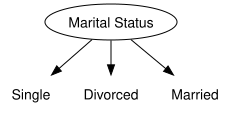

In [14]:
#| echo: false
#| fig-align: center
import graphviz

dot_data = """
digraph Tree {
    node [shape=oval, style="filled, rounded", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Marital Status", fillcolor="#ffffff"] ;
    1 [label="Single", fillcolor="#ffffff", shape="none"] ;
    2 [label="Divorced", fillcolor="#ffffff", shape="none"] ;
    3 [label="Married", fillcolor="#ffffff", shape="none"] ;
    0 -> 1 ;
    0 -> 2 ;
    0 -> 3 ; }
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

---

For a __Nominal (Categorical)__ attribute:

* In a __Binary split__ we divide the values into two groups.  

* In this case, we need to find an optimal partitioning of values into groups, which we discuss shortly.


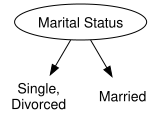

In [15]:
#| echo: false
import graphviz

dot_data = """
digraph Tree {
    node [shape=oval, style="filled, rounded", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Marital Status", fillcolor="#ffffff"] ;
    1 [label="Single,\\nDivorced", fillcolor="#ffffff", shape="none"] ;
    2 [label="Married", fillcolor="#ffffff", shape="none"] ;
    0 -> 1 ;
    0 -> 2 ; }
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

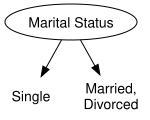

In [16]:
#| echo: false
dot_data = """
digraph Tree {
    node [shape=oval, style="filled, rounded", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Marital Status", fillcolor="#ffffff"] ;
    1 [label="Single", fillcolor="#ffffff", shape="none"] ;
    2 [label="Married,\\nDivorced", fillcolor="#ffffff", shape="none"] ;
    0 -> 1 ;
    0 -> 2 ; }
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

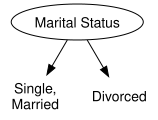

In [17]:
#| echo: false
dot_data = """
digraph Tree {
    node [shape=oval, style="filled, rounded", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Marital Status", fillcolor="#ffffff"] ;
    1 [label="Single,\\nMarried", fillcolor="#ffffff", shape="none"] ;
    2 [label="Divorced", fillcolor="#ffffff", shape="none"] ;
    0 -> 1 ;
    0 -> 2 ; }
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

---

For an __Ordinal__ attribute, we can use a multi-way split with as many partitions
as there are distinct values.

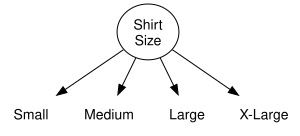

In [18]:
#| echo: false
#| fig-align: center
dot_data = """
digraph Tree {
    node [shape=oval, style="filled, rounded", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Shirt\\nSize", fillcolor="#ffffff"] ;
    1 [label="Small", fillcolor="#ffffff", shape="none"] ;
    2 [label="Medium", fillcolor="#ffffff", shape="none"] ;
    3 [label="Large", fillcolor="#ffffff", shape="none"] ;
    4 [label="X-Large", fillcolor="#ffffff", shape="none"] ;
    0 -> 1 ;
    0 -> 2 ;
    0 -> 3 ;
    0 -> 4 ; }
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

---

Or we can use a binary split as long we preserve the ordering of the values.


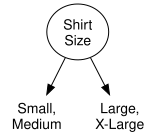

In [19]:
#| echo: false
dot_data = """
digraph Tree {
    node [shape=oval, style="filled, rounded", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Shirt\\nSize", fillcolor="#ffffff"] ;
    1 [label="Small,\\nMedium", fillcolor="#ffffff", shape="none"] ;
    2 [label="Large,\\nX-Large", fillcolor="#ffffff", shape="none"] ;
    0 -> 1 ;
    0 -> 2 ; }
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

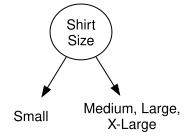

In [20]:
#| echo: false
dot_data = """
digraph Tree {
    node [shape=oval, style="filled, rounded", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Shirt\\nSize", fillcolor="#ffffff"] ;
    1 [label="Small", fillcolor="#ffffff", shape="none"] ;
    2 [label="Medium, Large,\\nX-Large", fillcolor="#ffffff", shape="none"] ;
    0 -> 1 ;
    0 -> 2 ; }
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

**Warning**

Be careful not to violate the ordering of values such as {Small, Large} and {Medium, X-Large}.


---

A __Continuous__ attribute can be handled two ways:


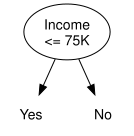

In [21]:
#| echo: false
#| fig-cap: 'It can be thresholded to form a binary split.'
dot_data = """
digraph Tree {
    node [shape=oval, style="filled, rounded", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Income\\n<= 75K", fillcolor="#ffffff"] ;
    1 [label="Yes", fillcolor="#ffffff", shape="none"] ;
    2 [label="No", fillcolor="#ffffff", shape="none"] ;
    0 -> 1 ;
    0 -> 2 ; }
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

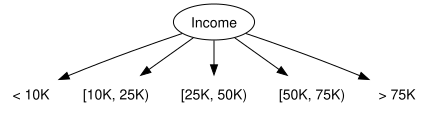

In [22]:
#| echo: false
#| fig-cap: 'Or it can be split into contiguous ranges to form an ordinal categorical attribute.'
dot_data = """
digraph Tree {
    node [shape=oval, style="filled, rounded", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Income", fillcolor="#ffffff"] ;
    1 [label="< 10K", fillcolor="#ffffff"shape="none"] ;
    2 [label="[10K, 25K)", fillcolor="#ffffff", shape="none"] ;
    3 [label="[25K, 50K)", fillcolor="#ffffff", shape="none"] ;
    4 [label="[50K, 75K)", fillcolor="#ffffff", shape="none"] ;
    5 [label="> 75K", fillcolor="#ffffff", shape="none"] ;
    0 -> 1 ;
    0 -> 2 ;
    0 -> 3 ;
    0 -> 4 ;
    0 -> 5 ; }
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

Note that finding good partitions for $k$ nominal attributes can be expensive, $\mathcal{O}(2^k)$, 
possibly involving combinatorial searching of groupings.  

However for ordinal or continuous attributes, sweeping through a range of $n$
threshold values can be more efficient if $n \approx k$. $\mathcal{O}(n)$ for a sorted list.


## Selecting Attribute and Test Condition

* Ideally, we want to pick attributes and test conditions that maximize the homogeneity of the splits.

* We can use an **impurity index** to measure the homogeneity in a node.

* We'll look at ways of measuring impurity of a node and then collective impurity of its child nodes.


## Node Impurity Measures

The following are three impurity indices, for a given node $t$:

$$
\begin{aligned}
\textnormal{Gini index} &= 1 - \sum_{i=0}^{c-1}  p_i(t)^2 \\
\textnormal{Entropy} &= -\sum_{i=0}^{c-1}  p_i(t) \log_2 p_i(t) \\
\textnormal{Classification error} &= 1 - \max_i p_i(t)
\end{aligned}
$$

where $p_i(t)$ is the **relative frequency** of training samples of class $i$ at a node $t$ and $c$ is the number of classes.

**Note**

By convention, we set $0 \log_2 0 = 0$ in entropy calculations.



## Node Impurity Measures

The following are three impurity indices, for a given node $t$:

$$
\begin{aligned}
\textnormal{Gini index} &= 1 - \sum_{i=0}^{c-1}  p_i(t)^2 \\
\textnormal{Entropy} &= -\sum_{i=0}^{c-1}  p_i(t) \log_2 p_i(t) \\
\textnormal{Classification error} &= 1 - \max_i p_i(t)
\end{aligned}
$$


All three impurity indices equal 0 when all the records at a node belong to the same class.

All three impurity indices reach their maximum value when the classes are evenly distributed among the child nodes.

---

We can plot the three impurity indices to get a sense of how they behave for **binary classification** problems.

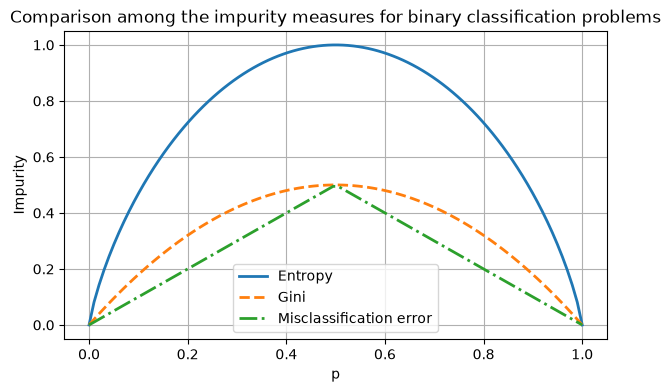

In [23]:
#| echo: false
#| fig-align: center
import numpy as np
import matplotlib.pyplot as plt

# Define probability values
p = np.linspace(0, 1, 100)

# Calculate impurity measures
entropy = -p * np.log2(p + 1e-9) - (1 - p) * np.log2(1 - p + 1e-9)  # Adding small epsilon to avoid log(0)
gini = 2 * p * (1 - p)
misclassification_error = 1 - np.maximum(p, 1 - p)

# Create the plot
plt.figure(figsize=(7, 4))
plt.plot(p, entropy, label='Entropy', linewidth=2)
plt.plot(p, gini, '--', label='Gini', linewidth=2)
plt.plot(p, misclassification_error, '-.', label='Misclassification error', linewidth=2)

# Add labels and title
plt.xlabel('p')
plt.ylabel('Impurity')
plt.title('Comparison among the impurity measures for binary classification problems')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

They all maintain the same ordering for every relative frequency, i.e., Entropy > Gini > Misclassification error.


## Impurity Example 1



| Node $t=N_1$ | Count | p |
| --- | --- | --- |
| Class=0 | 0 | $0/6 = 0$ |
| Class=1 | 6 | $6/6 = 1$ |

<br>

$$
\begin{aligned}
\textnormal{Gini} &= 1 - \left(\frac{0}{6}\right)^2 - \left(\frac{6}{6}\right)^2 = 0 \\
\textnormal{Entropy} &= -\left(\frac{0}{6} \log_2 \frac{0}{6} + \frac{6}{6} \log_2 \frac{6}{6}\right) = 0 \\
\textnormal{Error} &= 1 - \max\left[\frac{0}{6}, \frac{6}{6}\right] = 0
\end{aligned}
$$



## Impurity Example 2


| Node $t=N_2$ | Count | p |
| --- | --- | --- |
| Class=0 | 1 | $1/6 = 0.167$ |
| Class=1 | 5 | $5/6 = 0.833$ |

<br>

$$
\begin{aligned}
\textnormal{Gini} &= 1 - \left(\frac{1}{6}\right)^2 - \left(\frac{5}{6}\right)^2 = 0.278 \\
\textnormal{Entropy} &= -\left(\frac{1}{6} \log_2 \frac{1}{6} + \frac{5}{6} \log_2 \frac{5}{6}\right) = 0.650 \\
\textnormal{Error} &= 1 - \max\left[\frac{1}{6}, \frac{5}{6}\right] = 0.167
\end{aligned}
$$



## Impurity Example 3


| Node $t=N_3$ | Count |
| --- | --- |
| Class=0 | 3 |
| Class=1 | 3 |

<br>

$$
\begin{aligned}
\textnormal{Gini} &= 1 - \left(\frac{3}{6}\right)^2 - \left(\frac{3}{6}\right)^2 = 0.5 \\
\textnormal{Entropy} &= -\left(\frac{3}{6} \log_2 \frac{3}{6} + \frac{3}{6} \log_2 \frac{3}{6}\right) = 1 \\
\textnormal{Error} &= 1 - \max\left[\frac{3}{6}, \frac{3}{6}\right] = 0.5
\end{aligned}
$$

## Impurity Exercise

Calculate Gini impurity for the following node:

<br>

| Node $t=N_4$ | Count | p |
| --- | --- | --- |
| Class=0 | 3 |  |
| Class=1 | 6 |  |
| Class=2 | 1 |  |

<br>

$$
\textnormal{Gini} = 
$$

<!--
$$
\begin{aligned}
\textnormal{Gini} &= 1 - \left(\frac{3}{10}\right)^2 - \left(\frac{6}{10}\right)^2 - \left(\frac{1}{10}\right)^2 \\
&= 1 - \left(\frac{9}{100}\right) - \left(\frac{36}{10}\right) - \left(\frac{1}{100}\right) \\
&= 1 - 0.09 - 0.36 - 0.01 \\
&= 0.54
\end{aligned}
$$
-->


## Collective Impurity of Child Nodes

We can compute the _collective impurity_ of child nodes by taking a _weighted sum_ of the impurities of the child nodes.

$$
I(\textnormal{children}) = \sum_{j=1}^{k} \frac{N(v_j)}{N}\; I(v_j)
$$

Here we split $N$ training samples into $k$ child nodes, $v_j$ for $j=1, \ldots, k$.

$N(v_j)$ is the number of training samples at child node $v_j$ and $I(v_j)$ is the impurity at child node $v_j$.

The **gain** of a split is how much it reduces impurity:

$$
\Delta = I(\textnormal{parent}) - I(\textnormal{children})
$$

We pick the split with the largest $\Delta$.

## Collective Impurity Example

Let's compute collective impurity on our loans dataset to see which feature to split on.


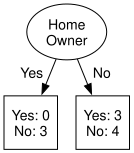

In [24]:
#| echo: false
#| fig-cap: '(a) Collective Entropy: 0.690'
dot_data = """
digraph Tree {
    node [shape=oval, style="filled", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Home\\nOwner", fillcolor="#ffffff"] ;
    1 [label="Yes: 0\\nNo: 3", fillcolor="#ffffff", shape="square"] ;
    2 [label="Yes: 3\\nNo: 4", fillcolor="#ffffff", shape="square"] ;
    0 -> 1 [labeldistance=2.5, labelangle=45, headlabel="Yes"] ;
    0 -> 2 [labeldistance=2.5, labelangle=-45, headlabel="No"] ; }
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

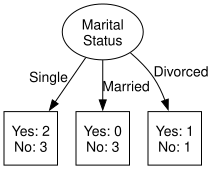

In [25]:
#| echo: false
#| fig-cap: '(b) Collective Entropy: 0.686'
dot_data = """
digraph Tree {
    node [shape=oval, style="filled", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Marital\\nStatus", fillcolor="#ffffff"] ;
    1 [label="Yes: 2\\nNo: 3", fillcolor="#ffffff", shape="square"] ;
    2 [label="Yes: 0\\nNo: 3", fillcolor="#ffffff", shape="square"] ;
    3 [label="Yes: 1\\nNo: 1", fillcolor="#ffffff", shape="square"] ;
    0 -> 1 [xlabel="Single"] ;
    0 -> 2 [label="Married"] ;
    0 -> 3 [xlabel="Divorced"] ; }
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

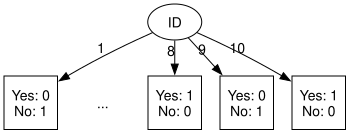

In [26]:
#| echo: false
#| fig-cap: '(c) Collective Entropy index: 0.00'
dot_data = """
digraph Tree {
    node [shape=oval, style="filled", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="ID", fillcolor="#ffffff"] ;
    1 [label="Yes: 0\\nNo: 1", fillcolor="#ffffff", shape="square"] ;
    2 [label="...", fillcolor="#ffffff", shape="none"] ;
    3 [label="Yes: 1\\nNo: 0", fillcolor="#ffffff", shape="square"] ;
    4 [label="Yes: 0\\nNo: 1", fillcolor="#ffffff", shape="square"] ;
    5 [label="Yes: 1\\nNo: 0", fillcolor="#ffffff", shape="square"] ;
    0 -> 1 [xlabel="1"] ;
    0 -> 2 [color="white"] ;
    0 -> 3 [xlabel="8"] ;
    0 -> 4 [xlabel="9"] ;
    0 -> 5 [xlabel="10"] ; }
"""

# Use graphviz to render the dot file
graph = graphviz.Source(dot_data)  
graph

**Tip**

Try calculating the collective Entropy for (a) and (b) and see if you get the same values.


**Important**

The collective entropy for (c) is 0. Why would we not want to use this node?


---

There are two ways to overcome this problem. 

1. One way is to _generate only binary decision trees_, thus avoiding the difficulty of handling attributes with varying
   number of partitions. This strategy is employed by decision tree classifiers such as **CART**. 
2. Another way is to modify the splitting criterion to take into account the number of partitions produced by the
   attribute. For example, in the **C4.5** decision tree algorithm, a measure known as **gain ratio** is used to compensate
   for attributes that produce a large number of child nodes.

CART stands for Classification And Regression Tree.


## Gain Ratio

See [@Tan2018, Chap. 3, p. 127]:

* Having a low impurity value alone is insufficient to find a good attribute test condition for a node. 
* Having more child nodes can make a decision tree more complex and consequently more susceptible to overfitting. 

Hence, the number of children produced by the splitting attribute should also be taken into consideration while deciding the best attribute test condition. 

## Gain Ratio Formula

$$
\text{Gain ratio} = \frac{\Delta_{\text{info}}}{\text{Split Info}} = \frac{\text{Entropy(Parent)} - \sum_{i=1}^{k} \frac{N(v_i)}{N} \text{Entropy}(v_i)}{- \sum_{i=1}^{k} \frac{N(v_i)}{N} \log_2 \frac{N(v_i)}{N}}
$$

where $N(v_i)$ is the number of samples assigned to node $v_i$ and $k$ is the number of child nodes. 

* The numerator is the gain $\Delta$ with $I = \text{Entropy}$, called the **Information Gain**: the reduction in entropy achieved by the split.
* The denominator, **Split Information**, is the entropy of the *child sizes*, not of the classes. It grows when the split produces many equally-sized child nodes, and it does not depend on which impurity measure is used.

## Gain Ratio: Changing Only the Numerator

Parent node: 4 Yes, 4 No, so $\text{Entropy(Parent)} = 1$. Both splits below make **two children of 4 samples**.


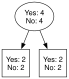

In [27]:
#| echo: false
#| fig-cap: '(A) Mixed children'
dot_data = """
digraph Tree {
    graph [size="2.5,1.1"] ;
    node [shape=oval, style="filled", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Yes: 4\\nNo: 4", fillcolor="#ffffff"] ;
    1 [label="Yes: 2\\nNo: 2", fillcolor="#ffffff", shape="square"] ;
    2 [label="Yes: 2\\nNo: 2", fillcolor="#ffffff", shape="square"] ;
    0 -> 1 ;
    0 -> 2 ; }
"""
graphviz.Source(dot_data)

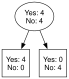

In [28]:
#| echo: false
#| fig-cap: '(B) Pure children'
dot_data = """
digraph Tree {
    graph [size="2.5,1.1"] ;
    node [shape=oval, style="filled", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Yes: 4\\nNo: 4", fillcolor="#ffffff"] ;
    1 [label="Yes: 4\\nNo: 0", fillcolor="#ffffff", shape="square"] ;
    2 [label="Yes: 0\\nNo: 4", fillcolor="#ffffff", shape="square"] ;
    0 -> 1 ;
    0 -> 2 ; }
"""
graphviz.Source(dot_data)

|  | (A) Mixed | (B) Pure |
|---|---|---|
| Info Gain (numerator) | $1 - \left(\tfrac{4}{8}\cdot 1 + \tfrac{4}{8}\cdot 1\right) = 0$ | $1 - \left(\tfrac{4}{8}\cdot 0 + \tfrac{4}{8}\cdot 0\right) = 1$ |
| Split Info (denominator) | $-2 \cdot \tfrac{4}{8}\log_2\tfrac{4}{8} = 1$ | $-2 \cdot \tfrac{4}{8}\log_2\tfrac{4}{8} = 1$ |
| **Gain Ratio** | $0/1 = \mathbf{0}$ | $1/1 = \mathbf{1}$ |

Same child sizes $\Rightarrow$ same Split Info. Only the class labels inside the children changed, and the numerator rewards the purer split.

## Gain Ratio: Changing Only the Denominator

Same parent (4 Yes, 4 No). Now every split has **pure children**, but a different number of them.


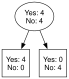

In [29]:
#| echo: false
#| fig-cap: '(B) 2 children of 4'
dot_data = """
digraph Tree {
    graph [size="2.5,1.1"] ;
    node [shape=oval, style="filled", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Yes: 4\\nNo: 4", fillcolor="#ffffff"] ;
    1 [label="Yes: 4\\nNo: 0", fillcolor="#ffffff", shape="square"] ;
    2 [label="Yes: 0\\nNo: 4", fillcolor="#ffffff", shape="square"] ;
    0 -> 1 ;
    0 -> 2 ; }
"""
graphviz.Source(dot_data)

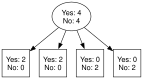

In [30]:
#| echo: false
#| fig-cap: '(C) 4 children of 2'
dot_data = """
digraph Tree {
    graph [size="2.5,1.1"] ;
    node [shape=oval, style="filled", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Yes: 4\\nNo: 4", fillcolor="#ffffff"] ;
    1 [label="Yes: 2\\nNo: 0", fillcolor="#ffffff", shape="square"] ;
    2 [label="Yes: 2\\nNo: 0", fillcolor="#ffffff", shape="square"] ;
    3 [label="Yes: 0\\nNo: 2", fillcolor="#ffffff", shape="square"] ;
    4 [label="Yes: 0\\nNo: 2", fillcolor="#ffffff", shape="square"] ;
    0 -> 1 ;
    0 -> 2 ;
    0 -> 3 ;
    0 -> 4 ; }
"""
graphviz.Source(dot_data)

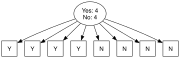

In [31]:
#| echo: false
#| fig-cap: '(D) 8 children of 1 (like ID)'
dot_data = """
digraph Tree {
    graph [size="2.5,1.1"] ;
    node [shape=oval, style="filled", color="black", fontname="helvetica"] ;
    edge [fontname="helvetica"] ;
    0 [label="Yes: 4\\nNo: 4", fillcolor="#ffffff"] ;
    1 [label="Y", fillcolor="#ffffff", shape="square"] ;
    2 [label="Y", fillcolor="#ffffff", shape="square"] ;
    3 [label="Y", fillcolor="#ffffff", shape="square"] ;
    4 [label="Y", fillcolor="#ffffff", shape="square"] ;
    5 [label="N", fillcolor="#ffffff", shape="square"] ;
    6 [label="N", fillcolor="#ffffff", shape="square"] ;
    7 [label="N", fillcolor="#ffffff", shape="square"] ;
    8 [label="N", fillcolor="#ffffff", shape="square"] ;
    0 -> 1 ; 0 -> 2 ; 0 -> 3 ; 0 -> 4 ;
    0 -> 5 ; 0 -> 6 ; 0 -> 7 ; 0 -> 8 ; }
"""
graphviz.Source(dot_data)

|  | (B) $k=2$ | (C) $k=4$ | (D) $k=8$ |
|---|---|---|---|
| Info Gain (numerator) | $1$ | $1$ | $1$ |
| Split Info (denominator) | $-2\cdot\tfrac{1}{2}\log_2\tfrac{1}{2} = 1$ | $-4\cdot\tfrac{1}{4}\log_2\tfrac{1}{4} = 2$ | $-8\cdot\tfrac{1}{8}\log_2\tfrac{1}{8} = 3$ |
| **Gain Ratio** | $\mathbf{1}$ | $\mathbf{0.5}$ | $\mathbf{0.33}$ |

Information Gain cannot tell these apart. Split Info grows as $\log_2 k$ for $k$ equal-sized children, so the gain ratio penalizes the many-way split.

## Split Info Depends Only on Child Sizes

Split Info is just the entropy of the *child sizes*; the class labels never enter it. For $N = 8$ samples:

| Child sizes | Split Info |
|---|---|
| 7, 1 | $-\tfrac{7}{8}\log_2\tfrac{7}{8} - \tfrac{1}{8}\log_2\tfrac{1}{8} = 0.544$ |
| 6, 2 | $-\tfrac{6}{8}\log_2\tfrac{6}{8} - \tfrac{2}{8}\log_2\tfrac{2}{8} = 0.811$ |
| 4, 4 | $1$ |
| 2, 2, 2, 2 | $2$ |
| 1, 1, 1, 1, 1, 1, 1, 1 | $3$ |

* More children $\Rightarrow$ larger Split Info.
* For a fixed number of children, Split Info is largest when they are equal-sized.
* Caveat: a lopsided split (7, 1) has a small denominator, which can inflate the gain ratio. C4.5 only considers attributes whose information gain is at least average.

## Gain Ratio Example

Let's compare the Gain Ratio for **Home Owner** and **Marital Status** attributes using the loans dataset.

Recall from the earlier example that the parent node has 3 Yes and 7 No defaulters (10 total samples).

**Parent node entropy:**

$$
\text{Entropy(Parent)} = -\frac{3}{10} \log_2 \frac{3}{10} - \frac{7}{10} \log_2 \frac{7}{10} = 0.881
$$

## Ex: Gain Ratio for Home Owner Attribute

The Home Owner attribute splits the data into 2 child nodes:

- Yes: 0 Yes, 3 No (3 samples)
- No: 3 Yes, 4 No (7 samples)

From the earlier calculation, the Information Gain is:

$$
\Delta_{\text{info}} = 0.881 - \left(\frac{3}{10} \times 0 + \frac{7}{10} \times 0.985\right) = 0.192
$$

Now we calculate the Split Information:

$$
\text{Split Info} = -\frac{3}{10} \log_2 \frac{3}{10} - \frac{7}{10} \log_2 \frac{7}{10} = 0.881
$$

Therefore, the Gain Ratio is:

$$
\text{Gain Ratio(Home Owner)} = \frac{0.192}{0.881} = 0.218
$$

## Ex: Gain Ratio for Marital Status Attribute

The Marital Status attribute splits the data into 3 child nodes:

- Single: 2 Yes, 3 No (5 samples)
- Married: 0 Yes, 3 No (3 samples)
- Divorced: 1 Yes, 1 No (2 samples)

From the earlier calculation, the Information Gain is:

$$
\Delta_{\text{info}} = 0.881 - \left(\frac{5}{10} \times 0.971 + \frac{3}{10} \times 0 + \frac{2}{10} \times 1\right) = 0.195
$$

Now we calculate the Split Information:

$$
\text{Split Info} = -\frac{5}{10} \log_2 \frac{5}{10} - \frac{3}{10} \log_2 \frac{3}{10} - \frac{2}{10} \log_2 \frac{2}{10} = 1.486
$$

Therefore, the Gain Ratio is:

$$
\text{Gain Ratio(Marital Status)} = \frac{0.195}{1.486} = 0.131
$$

## Example: Comparison of Gain Ratios

| Attribute | Information Gain | Split Info | Gain Ratio |
|-----------|-----------------|------------|------------|
| Home Owner | 0.192 | 0.881 | **0.218** |
| Marital Status | 0.195 | 1.486 | 0.131 |

Although Marital Status has a slightly higher Information Gain, it has a **lower Gain Ratio** because it splits the data into 3 child nodes rather than 2. 

The Gain Ratio penalizes attributes that create more splits, making **Home Owner** the preferred choice.

## Option 1: Binary Splits Only (CART)

* Gain ratio was C4.5's fix for many-way splits (option 2). CART takes option 1 instead: **every test condition is a binary split**.
* With every split binary, the many-children penalty is gone, so CART uses the plain gain $\Delta$ rather than gain ratio.
* Binary splits also mean an attribute can have *several* candidate test conditions. A nominal attribute with $k$ values has $2^{k-1} - 1$ ways to group its values into two children, so Marital Status (3 values) has 3.
* Choosing a split now means choosing the attribute **and** its test condition: we score every (attribute, grouping) pair and keep the best.
* CART scores splits with **Gini** impurity. Entropy would also work and usually picks the same split. Gini is also scikit-learn's default (`criterion='gini'`), which we'll use below.


## Ex: Best Binary Split Using Gini

The loans parent node (3 Yes, 7 No) has four candidate binary splits: one for Home Owner and three groupings of Marital Status.

![](figs/L14-splitting-criteria-gini.png)

We pick the split with the largest gain $\Delta$, now with $I = \text{Gini}$, i.e., the lowest collective Gini impurity.

* Home Owner and *Single+Divorced vs Married* **tie** at 0.343: both produce children with 0/3 and 3/4 Yes/No counts.
* Different test conditions can produce the same partition counts. A tree builder breaks such ties arbitrarily (scikit-learn by random feature order, set by `random_state`).

## Ex: Computing the Gini Gains

In [32]:
def gini_impurity(yes_count, no_count):
    """Calculate Gini impurity for a node"""
    total = yes_count + no_count
    if total == 0:
        return 0
    
    p_yes = yes_count / total
    p_no = no_count / total
    
    gini = 1 - (p_yes**2 + p_no**2)
    return gini

def weighted_gini(n1_yes, n1_no, n2_yes, n2_no):
    """Calculate weighted average Gini impurity after split"""
    n1_total = n1_yes + n1_no
    n2_total = n2_yes + n2_no
    total = n1_total + n2_total
    
    gini_n1 = gini_impurity(n1_yes, n1_no)
    gini_n2 = gini_impurity(n2_yes, n2_no)
    
    weighted_gini = (n1_total/total) * gini_n1 + (n2_total/total) * gini_n2
    return weighted_gini

# Parent node
parent_yes = 3
parent_no = 7
parent_gini = gini_impurity(parent_yes, parent_no)

print("=" * 60)
print("PARENT NODE")
print("=" * 60)
print(f"Yes: {parent_yes}, No: {parent_no}")
print(f"Gini Impurity: {parent_gini:.3f}")
print()

# Define all four splits
splits = {
    "Home Owner": {
        "N1": {"yes": 0, "no": 3},  # Yes (owns home)
        "N2": {"yes": 3, "no": 4}   # No (doesn't own home)
    },
    "Marital Status (Split 1: Single vs Married+Divorced)": {
        "N1": {"yes": 2, "no": 3},  # Single
        "N2": {"yes": 1, "no": 4}   # Married, Divorced
    },
    "Marital Status (Split 2: Single+Married vs Divorced)": {
        "N1": {"yes": 2, "no": 6},  # Single, Married
        "N2": {"yes": 1, "no": 1}   # Divorced
    },
    "Marital Status (Split 3: Single+Divorced vs Married)": {
        "N1": {"yes": 3, "no": 4},  # Single, Divorced
        "N2": {"yes": 0, "no": 3}   # Married
    }
}

# Calculate for each split
results = []
for split_name, nodes in splits.items():
    n1_yes = nodes["N1"]["yes"]
    n1_no = nodes["N1"]["no"]
    n2_yes = nodes["N2"]["yes"]
    n2_no = nodes["N2"]["no"]
    
    gini_n1 = gini_impurity(n1_yes, n1_no)
    gini_n2 = gini_impurity(n2_yes, n2_no)
    weighted_gini_value = weighted_gini(n1_yes, n1_no, n2_yes, n2_no)
    gini_gain = parent_gini - weighted_gini_value
    
    results.append({
        'name': split_name,
        'weighted_gini': weighted_gini_value,
        'gini_gain': gini_gain,
        'gini_n1': gini_n1,
        'gini_n2': gini_n2,
        'n1_yes': n1_yes,
        'n1_no': n1_no,
        'n2_yes': n2_yes,
        'n2_no': n2_no
    })
    
    print("=" * 60)
    print(f"SPLIT: {split_name}")
    print("=" * 60)
    print(f"Node N1: Yes={n1_yes}, No={n1_no}, Total={n1_yes+n1_no}")
    print(f"  Gini(N1) = {gini_n1:.3f}")
    print(f"Node N2: Yes={n2_yes}, No={n2_no}, Total={n2_yes+n2_no}")
    print(f"  Gini(N2) = {gini_n2:.3f}")
    print(f"\nWeighted Gini (after split): {weighted_gini_value:.3f}")
    print(f"Gini Gain: {gini_gain:.3f}")
    print()

# Summary: Find best split
print("=" * 60)
print("SUMMARY - BEST SPLIT")
print("=" * 60)
results_sorted = sorted(results, key=lambda x: x['gini_gain'], reverse=True)
for i, result in enumerate(results_sorted, 1):
    print(f"{i}. {result['name']}")
    print(f"   Weighted Gini: {result['weighted_gini']:.3f}, Gini Gain: {result['gini_gain']:.3f}")
print()
best_gain = results_sorted[0]['gini_gain']
best = [r['name'] for r in results_sorted if np.isclose(r['gini_gain'], best_gain)]
print(f"Maximum Gini Gain: {best_gain:.3f}, achieved by:")
for name in best:
    print(f"  {name}")

PARENT NODE
Yes: 3, No: 7
Gini Impurity: 0.420

SPLIT: Home Owner
Node N1: Yes=0, No=3, Total=3
  Gini(N1) = 0.000
Node N2: Yes=3, No=4, Total=7
  Gini(N2) = 0.490

Weighted Gini (after split): 0.343
Gini Gain: 0.077

SPLIT: Marital Status (Split 1: Single vs Married+Divorced)
Node N1: Yes=2, No=3, Total=5
  Gini(N1) = 0.480
Node N2: Yes=1, No=4, Total=5
  Gini(N2) = 0.320

Weighted Gini (after split): 0.400
Gini Gain: 0.020

SPLIT: Marital Status (Split 2: Single+Married vs Divorced)
Node N1: Yes=2, No=6, Total=8
  Gini(N1) = 0.375
Node N2: Yes=1, No=1, Total=2
  Gini(N2) = 0.500

Weighted Gini (after split): 0.400
Gini Gain: 0.020

SPLIT: Marital Status (Split 3: Single+Divorced vs Married)
Node N1: Yes=3, No=4, Total=7
  Gini(N1) = 0.490
Node N2: Yes=0, No=3, Total=3
  Gini(N2) = 0.000

Weighted Gini (after split): 0.343
Gini Gain: 0.077

SUMMARY - BEST SPLIT
1. Home Owner
   Weighted Gini: 0.343, Gini Gain: 0.077
2. Marital Status (Split 3: Single+Divorced vs Married)
   Weighted G

## Splitting Continuous Attributes

For quantitative attributes like _Annual Income_, we need to find some threshold $\tau$ that
minimizes the impurity index.

The following table illustrates the process.

![](figs/L14-splitting-continuous-attribs.png)


**Procedure:**

1. Sort all the training samples by _Annual Income_ in increasing order.
2. Pick thresholds half way between consecutive values.
3. Compute the Gini impurity index for each threshold.
4. Select the threshold that minimizes the Gini impurity index.

In [33]:
def gini_impurity(yes_count, no_count):
    """Calculate Gini impurity for a node"""
    total = yes_count + no_count
    if total == 0:
        return 0
    
    p_yes = yes_count / total
    p_no = no_count / total
    
    gini = 1 - (p_yes**2 + p_no**2)
    return gini

def weighted_gini_split(left_yes, left_no, right_yes, right_no):
    """Calculate weighted Gini impurity for a binary split"""
    left_total = left_yes + left_no
    right_total = right_yes + right_no
    total = left_total + right_total
    
    if total == 0:
        return 0
    
    gini_left = gini_impurity(left_yes, left_no)
    gini_right = gini_impurity(right_yes, right_no)
    
    weighted_gini = (left_total/total) * gini_left + (right_total/total) * gini_right
    return weighted_gini

# Data from the table
sorted_values = [60, 70, 75, 85, 90, 95, 100, 120, 125, 220]
classes = ['No', 'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No', 'No']

# Calculate split positions (midpoints between consecutive values)
split_positions = []
for i in range(len(sorted_values) - 1):
    split_pos = (sorted_values[i] + sorted_values[i+1]) / 2
    split_positions.append(split_pos)

# Parent node statistics
parent_yes = classes.count('Yes')
parent_no = classes.count('No')
parent_gini = gini_impurity(parent_yes, parent_no)

print("=" * 80)
print("CONTINUOUS ATTRIBUTE: Annual Income")
print("=" * 80)
print(f"Parent Node: Yes={parent_yes}, No={parent_no}")
print(f"Parent Gini Impurity: {parent_gini:.3f}")
print()

print("=" * 80)
print("EVALUATING ALL POSSIBLE SPLITS")
print("=" * 80)

best_split = None
best_gini = float('inf')
best_gain = -float('inf')

results = []

for i, split_pos in enumerate(split_positions):
    # Count classes on left (<= split) and right (> split)
    left_yes = 0
    left_no = 0
    right_yes = 0
    right_no = 0
    
    for j, value in enumerate(sorted_values):
        if value <= split_pos:
            if classes[j] == 'Yes':
                left_yes += 1
            else:
                left_no += 1
        else:
            if classes[j] == 'Yes':
                right_yes += 1
            else:
                right_no += 1
    
    # Calculate weighted Gini
    weighted_gini = weighted_gini_split(left_yes, left_no, right_yes, right_no)
    gini_gain = parent_gini - weighted_gini
    
    results.append({
        'split_position': split_pos,
        'left_yes': left_yes,
        'left_no': left_no,
        'right_yes': right_yes,
        'right_no': right_no,
        'weighted_gini': weighted_gini,
        'gini_gain': gini_gain
    })
    
    print(f"Split at {split_pos:6.1f}:")
    print(f"  Left  (<=): Yes={left_yes}, No={left_no}, Total={left_yes+left_no}")
    print(f"  Right ( >): Yes={right_yes}, No={right_no}, Total={right_yes+right_no}")
    print(f"  Weighted Gini: {weighted_gini:.3f}")
    print(f"  Gini Gain: {gini_gain:.3f}")
    
    if weighted_gini < best_gini:
        best_gini = weighted_gini
        best_split = split_pos
        best_gain = gini_gain
    
    print()

print("=" * 80)
print("BEST SPLIT")
print("=" * 80)
print(f"Best Split Position: {best_split}")
print(f"Minimum Weighted Gini: {best_gini:.3f}")
print(f"Maximum Gini Gain: {best_gain:.3f}")

# Show the split details
best_result = [r for r in results if r['split_position'] == best_split][0]
print(f"\nSplit Details (Annual Income <= {best_split}):")
print(f"  Left  (<=): Yes={best_result['left_yes']}, No={best_result['left_no']}")
print(f"  Right ( >): Yes={best_result['right_yes']}, No={best_result['right_no']}")

CONTINUOUS ATTRIBUTE: Annual Income
Parent Node: Yes=3, No=7
Parent Gini Impurity: 0.420

EVALUATING ALL POSSIBLE SPLITS
Split at   65.0:
  Left  (<=): Yes=0, No=1, Total=1
  Right ( >): Yes=3, No=6, Total=9
  Weighted Gini: 0.400
  Gini Gain: 0.020

Split at   72.5:
  Left  (<=): Yes=0, No=2, Total=2
  Right ( >): Yes=3, No=5, Total=8
  Weighted Gini: 0.375
  Gini Gain: 0.045

Split at   80.0:
  Left  (<=): Yes=0, No=3, Total=3
  Right ( >): Yes=3, No=4, Total=7
  Weighted Gini: 0.343
  Gini Gain: 0.077

Split at   87.5:
  Left  (<=): Yes=1, No=3, Total=4
  Right ( >): Yes=2, No=4, Total=6
  Weighted Gini: 0.417
  Gini Gain: 0.003

Split at   92.5:
  Left  (<=): Yes=2, No=3, Total=5
  Right ( >): Yes=1, No=4, Total=5
  Weighted Gini: 0.400
  Gini Gain: 0.020

Split at   97.5:
  Left  (<=): Yes=3, No=3, Total=6
  Right ( >): Yes=0, No=4, Total=4
  Weighted Gini: 0.300
  Gini Gain: 0.120

Split at  110.0:
  Left  (<=): Yes=3, No=4, Total=7
  Right ( >): Yes=0, No=3, Total=3
  Weighted G

## Run Decision Tree on Loans Data Set

Let's run the Scikit-learn Decision Tree, `sklearn.tree`, on the loans data set.

`sklearn.tree` requires all fields to be numeric.

So first we have to convert the categorical fields to category index numeric fields.

In [34]:
#| code-fold: false
loans['Defaulted Borrower'] = loans['Defaulted Borrower'].cat.codes
loans['Home Owner'] = loans['Home Owner'].cat.codes
loans['Marital Status'] = loans['Marital Status'].cat.codes
loans.head()

,Home Owner,Marital Status,Annual Income,Defaulted Borrower
ID,,,,
1,1,2,125000,0
2,0,1,100000,0
3,0,2,70000,0
4,1,1,120000,0
5,0,0,95000,1


---

Then the independent variables are all the fields except the "Defaulted Borrower" field, which we'll assign to `X`.

The dependent variable is the "Defaulted Borrower" field, which we'll assign to `y`.

In [35]:
#| code-fold: false
from sklearn import tree

X = loans.drop('Defaulted Borrower', axis=1)
y = loans['Defaulted Borrower']

<br>

`X`:

In [36]:
#| echo: false
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 1 to 10
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Home Owner      10 non-null     int8 
 1   Marital Status  10 non-null     int8 
 2   Annual Income   10 non-null     int64
dtypes: int64(1), int8(2)
memory usage: 232.0 bytes


`y`:

In [37]:
#| echo: false
y.info()

<class 'pandas.Series'>
RangeIndex: 10 entries, 1 to 10
Series name: Defaulted Borrower
Non-Null Count  Dtype
--------------  -----
10 non-null     int8 
dtypes: int8(1)
memory usage: 142.0 bytes


---

Let's fit a decision tree to the data.

In [38]:
#| code-fold: false
clf = tree.DecisionTreeClassifier(criterion='gini', random_state=42)
clf = clf.fit(X, y)

Let's plot the tree.

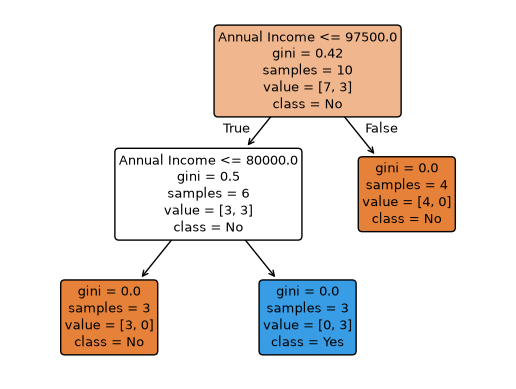

In [39]:
#| echo: false
annotations = tree.plot_tree(clf, 
               filled=True, 
               rounded=True,
               # max_depth=2,
               # impurity=False,
               feature_names=loans.drop('Defaulted Borrower', axis=1).columns,
               class_names=['No', 'Yes'])

Interestingly, the tree was built using only the Income field.

That's arguably an advantage of Decision Trees: they automatically perform feature selection.


# Ensemble Methods

(See @Tan2018, Chapter 4)

Motivated around the idea that combining several noisy classifiers can result in a better prediction
under certain conditions.

* The base classifiers are independent
* The base classifiers are noisy (high variance)
* The base classifiers are low (ideally zero) bias

## Bias and Variance

Recall bias and variance from [Generalization](./07-Generalization.qmd#bias-and-variance):
__bias__ is error from a model too simple to capture the pattern (a shallow tree underfits);
__variance__ is error from a model so flexible that it changes with every training sample (a deep tree overfits).

A fully grown tree is low bias, high variance. Averaging many such trees keeps the low bias and averages away much of the variance -- __ensembles reduce variance.__

## Random Forests

Random forests are an ensemble of decision trees that:

* Train each tree on a **bootstrap sample**: $N$ points drawn *with replacement* from the $N$ training points.
* At **each split**, consider only a random subset of the features (`max_features` in scikit-learn).
* Grow each tree to completion (low bias, high variance).
* Take a majority vote of the trees to form the final prediction.

**Note**

Why not one tree on all the data? A deep tree's problem is variance, not too little data. Averaging $B$ trees with pairwise correlation $\rho$ shrinks variance to $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$. The bootstrap and the feature subsampling exist to make the trees differ, which lowers $\rho$.


## Titanic Example

We'll use the [Titanic data set](https://www.kaggle.com/competitions/titanic) and
excerpts of this [Kaggle tutorial](https://www.kaggle.com/code/jhoward/how-random-forests-really-work/)
to illustrate the concepts of overfitting and random forests.

In [40]:
import pandas as pd

import os
import urllib.request

# Check if the directory exists, if not, create it
if not os.path.exists('data/titanic'):
    os.makedirs('data/titanic')

if not os.path.exists('data/titanic/train.csv'):
    url = 'https://tools4ds.github.io/ds701/data/titanic/train.csv'
    urllib.request.urlretrieve(url, 'data/titanic/train.csv')

df_train = pd.read_csv('data/titanic/train.csv', index_col='PassengerId')

if not os.path.exists('data/titanic/test.csv'):
    url = 'https://tools4ds.github.io/ds701/data/titanic/test.csv'
    urllib.request.urlretrieve(url, 'data/titanic/test.csv')

df_test = pd.read_csv('data/titanic/test.csv', index_col='PassengerId')

---

Let's look at the training data.

In [41]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


We can see that there are 891 entries with 11 fields. 'Age', 'Cabin', and 'Embarked' have missing values.

---

In [42]:
df_train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---

Let's look at the test data.

In [43]:
df_test.info()
df_test.head()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    str    
 2   Sex       418 non-null    str    
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    str    
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     str    
 9   Embarked  418 non-null    str    
dtypes: float64(2), int64(3), str(5)
memory usage: 32.8 KB


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


There are 418 entries in the test set with same fields except for 'Survived', which is what we need to predict.

---

We'll do some data cleaning and preparation.

In [44]:
import numpy as np

def proc_data(df):
    df['Fare'] = df.Fare.fillna(0)
    df.fillna(modes, inplace=True) # Fill missing values with the mode
    df['LogFare'] = np.log1p(df['Fare'])  # Create a new column for the log of the fare + 1
    df['Embarked'] = pd.Categorical(df.Embarked)  # Convert to categorical
    df['Sex'] = pd.Categorical(df.Sex)  # Convert to categorical

modes = df_train.mode().iloc[0] # Get the mode for each column

proc_data(df_train)
proc_data(df_test)

Look at the dataframes again.

In [45]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    int64   
 2   Name      891 non-null    str     
 3   Sex       891 non-null    category
 4   Age       891 non-null    float64 
 5   SibSp     891 non-null    int64   
 6   Parch     891 non-null    int64   
 7   Ticket    891 non-null    str     
 8   Fare      891 non-null    float64 
 9   Cabin     891 non-null    str     
 10  Embarked  891 non-null    category
 11  LogFare   891 non-null    float64 
dtypes: category(2), float64(3), int64(4), str(3)
memory usage: 71.5 KB


In [46]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 892 to 1309
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Pclass    418 non-null    int64   
 1   Name      418 non-null    str     
 2   Sex       418 non-null    category
 3   Age       418 non-null    float64 
 4   SibSp     418 non-null    int64   
 5   Parch     418 non-null    int64   
 6   Ticket    418 non-null    str     
 7   Fare      418 non-null    float64 
 8   Cabin     418 non-null    str     
 9   Embarked  418 non-null    category
 10  LogFare   418 non-null    float64 
dtypes: category(2), float64(3), int64(3), str(3)
memory usage: 30.4 KB


---

We'll create lists of features by type.

In [47]:
#| code-fold: false
cats=["Sex","Embarked"]  # Categorical
conts=['Age', 'SibSp', 'Parch', 'LogFare',"Pclass"]  # Continuous
dep="Survived"  # Dependent variable

---

Let's explore some fields starting with survival rate by gender.

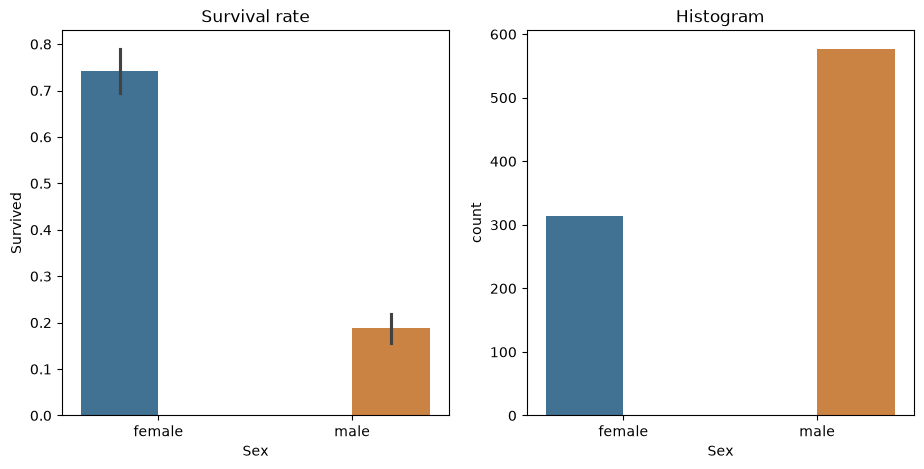

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
fig,axs = plt.subplots(1,2, figsize=(11,5))
sns.barplot(data=df_train, y='Survived', x="Sex", ax=axs[0], hue="Sex", palette=["#3374a1","#e1812d"]).set(title="Survival rate")
sns.countplot(data=df_train, x="Sex", ax=axs[1], hue="Sex", palette=["#3374a1","#e1812d"]).set(title="Histogram");

Indeed, "women and children first" was enforced on the Titanic.

---

Since we don't have labels for the test data, we'll split the training data into training and validation.

In [49]:
#| code-fold: false
from numpy import random
from sklearn.model_selection import train_test_split

random.seed(42)
trn_df,val_df = train_test_split(df_train, test_size=0.25)

# Replace categorical fields with numeric codes
trn_df[cats] = trn_df[cats].apply(lambda x: x.cat.codes)
val_df[cats] = val_df[cats].apply(lambda x: x.cat.codes)

---

Let's split the independent (input) variables from the dependent (output) variable.

In [50]:
#| code-fold: false
def xs_y(df):
    xs = df[cats+conts].copy()
    return xs,df[dep] if dep in df else None

trn_xs,trn_y = xs_y(trn_df)
val_xs,val_y = xs_y(val_df)

---

Here's the predictions for our extremely simple model, where `female` is coded as `0`:

In [51]:
#| code-fold: false
preds = val_xs.Sex==0

We'll use mean absolute error to measure how good this model is:

In [52]:
#| code-fold: false
from sklearn.metrics import mean_absolute_error
mean_absolute_error(val_y, preds)

0.21524663677130046

---

Alternatively, we could try splitting on a continuous column. We have to use a somewhat different chart to see how this might work -- here's an example of how we could look at `LogFare`:

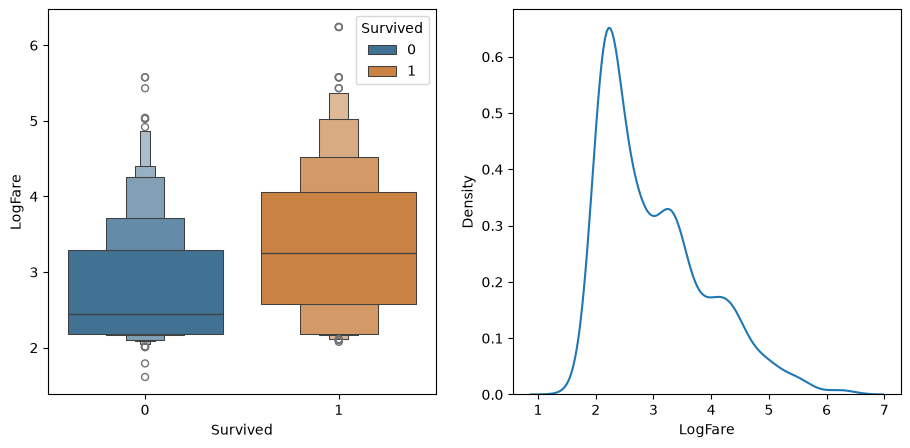

In [53]:
df_fare = trn_df[trn_df.LogFare>0]
fig,axs = plt.subplots(1,2, figsize=(11,5))
sns.boxenplot(data=df_fare, x=dep, y="LogFare", ax=axs[0], hue=dep, palette=["#3374a1","#e1812d"])
sns.kdeplot(data=df_fare, x="LogFare", ax=axs[1]);

The [boxenplot](https://seaborn.pydata.org/generated/seaborn.boxenplot.html) above shows quantiles of `LogFare` for each group of `Survived==0` and `Survived==1`. 

It shows that the average `LogFare` for passengers that didn't survive is around `2.5`, and for those that did it's around `3.2`. 

So it seems that people that paid more for their tickets were more likely to get put on a lifeboat.

---

Let's create a simple model based on this observation:

In [54]:
#| code-fold: false
preds = val_xs.LogFare>2.7

...and test it out:

In [55]:
#| code-fold: false
mean_absolute_error(val_y, preds)

0.336322869955157

This is quite a bit less accurate than our model that used `Sex` as the single binary split.

## Full Decision Tree

Ok. Let's build a decision tree model using all the features.

In [56]:
#| code-fold: false
clf = tree.DecisionTreeClassifier(criterion='gini', random_state=42)
clf = clf.fit(trn_xs, trn_y)

Let's draw the tree.

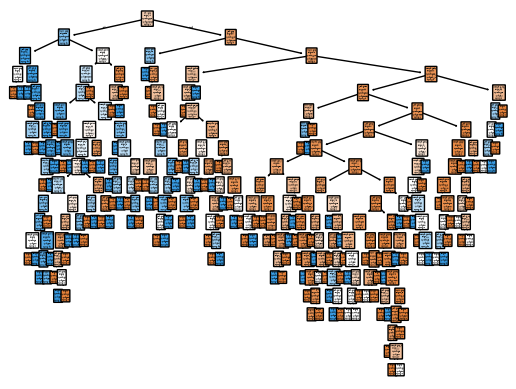

In [57]:
#| code-fold: false
annotations = tree.plot_tree(clf, 
               filled=True, 
               rounded=True,
               feature_names=trn_xs.columns,
               class_names=['No', 'Yes'])

## Full Tree -- Evaluation Error

Let's see how it does on the validation set.

In [58]:
#| code-fold: false
preds = clf.predict(val_xs)
mean_absolute_error(val_y, preds)

0.2645739910313901

That is quite a bit worse than splitting on `Sex` alone!!


## Stopping Criteria -- Minimum Samples Split

Let's train the decision tree again but with stopping criteria based on the number of samples in a node.

In [59]:
#| code-fold: false
clf = tree.DecisionTreeClassifier(criterion='gini', random_state=42, min_samples_split=20)
clf = clf.fit(trn_xs, trn_y)

Let's draw the tree.

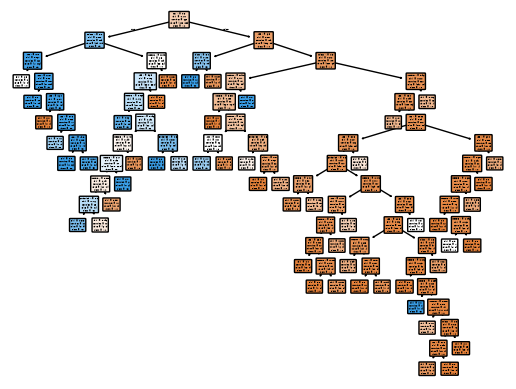

In [60]:
#| code-fold: false
annotations = tree.plot_tree(clf, 
               filled=True, 
               rounded=True,
               feature_names=trn_xs.columns,
               class_names=['No', 'Yes'])

## Min Samples Split -- Evaluation Error

Let's see how it does on the validation set.

In [61]:
#| code-fold: false
preds = clf.predict(val_xs)
mean_absolute_error(val_y, preds)

0.18834080717488788

## Decision Tree -- Maximum Depth

Let's train the decision tree again but with a maximum depth of 3.

In [62]:
#| code-fold: false
clf = tree.DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=3)
clf = clf.fit(trn_xs, trn_y)

Let's draw the tree.

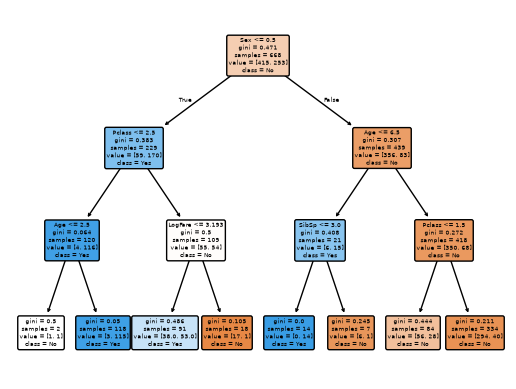

In [63]:
#| code-fold: false
annotations = tree.plot_tree(clf, 
               filled=True, 
               rounded=True,
               feature_names=trn_xs.columns,
               class_names=['No', 'Yes'])

## Maximum Depth -- Evaluation Error

Let's see how it does on the validation set.

In [64]:
#| code-fold: false
preds = clf.predict(val_xs)
mean_absolute_error(val_y, preds)

0.19730941704035873

## Random Forest

Let's try a random forest.

In [65]:
#| code-fold: false
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf = clf.fit(trn_xs, trn_y)

Let's see how it does on the validation set.

In [66]:
#| code-fold: false
preds = clf.predict(val_xs)
mean_absolute_error(val_y, preds)

0.21076233183856502

Better than the fully grown tree (0.265), but not better than our limited single trees (about 0.19). Why not?

## Why Didn't the Forest Win?

* __Its trees are grown to completion.__ With only 668 training passengers and 7 features, each deep tree memorizes
  noisy labels. A noisy passenger lands in about 63% of the bootstrap samples, so many trees memorize the *same* noise,
  and averaging cannot cancel what the trees share.
* __One validation set is a noisy judge.__ With 223 validation passengers and an error near 0.2, the standard error is
  $\sqrt{0.2 \cdot 0.8 / 223} \approx 0.027$. A gap of 0.02 between two models is within that noise.
* So: tune the forest, and choose its hyperparameters with __cross-validation__ on the training data, not by
  checking the validation score ([Generalization](./07-Generalization.qmd)).


## Tuning the Forest

Limit how small a leaf can be (`min_samples_leaf`), scoring each setting by repeated 5-fold cross-validation on the training data only.

In [67]:
#| code-fold: false
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0)
for leaf in [1, 2, 3, 5, 10, 20]:
    rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=leaf, random_state=42)
    cv_error = 1 - cross_val_score(rf, trn_xs, trn_y, cv=cv).mean()
    print(f"min_samples_leaf={leaf:2d}: CV error {cv_error:.3f}")

min_samples_leaf= 1: CV error 0.194
min_samples_leaf= 2: CV error 0.182
min_samples_leaf= 3: CV error 0.178
min_samples_leaf= 5: CV error 0.184
min_samples_leaf=10: CV error 0.188
min_samples_leaf=20: CV error 0.211


Cross-validation picks `min_samples_leaf=3`. Now, once, the validation set:

In [68]:
#| code-fold: false
clf = RandomForestClassifier(n_estimators=100, min_samples_leaf=3, random_state=42)
clf = clf.fit(trn_xs, trn_y)
mean_absolute_error(val_y, clf.predict(val_xs))

0.17488789237668162

## Tuning the Forest: Takeaways

* The tuned forest has the lowest validation error in this lecture (0.175 vs. 0.188 for the best single tree), but by
  our own yardstick that gap is within the noise.
* "Grow each tree to completion" is the default, not a rule. On small, noisy data a minimum leaf size helps,
  because averaging removes only the variance the trees *don't* share.
* Why so close? Titanic is small, has few features, and is dominated by one (`Sex`), so there is little variance left
  for averaging to remove. Forests pull further ahead with more data and more features.


## Summary

Decision trees -- five things we did:

1. __Grow a tree greedily.__ At each node, try every (attribute, test condition) pair and keep the one with the largest
   gain $\Delta = I(\textnormal{parent}) - I(\textnormal{children})$. The impurity $I$ can be Gini, entropy, or classification error.
1. __Handle many-way splits.__ Gain alone favors splits into many small children (the ID attribute). C4.5 divides by
   Split Info (__gain ratio__); CART allows only __binary splits__ and uses the plain gain with Gini.
1. __Split continuous attributes__ at a threshold $\tau$, chosen by the same gain criterion.
1. __Control overfitting.__ On Titanic, the fully grown tree had a validation error of 0.265, worse than the one-rule
   "women survive" model (0.215). Stopping criteria (`min_samples_split`, `max_depth`) brought it down to about 0.19.
1. __Reduce variance with random forests.__ Average many deep trees, each trained on a bootstrap sample with random
   feature subsets at every split. Untuned (0.211) it beat only the full tree; with `min_samples_leaf` chosen by
   cross-validation it reached 0.175, the lowest validation error in the lecture, though only narrowly.


## Next: $k$-Nearest Neighbors Classifiers

* Another classifier with the same bias--variance trade-off and a different knob: the number of neighbors $k$ plays
  the role that depth played today.
* Small $k$ overfits, like a fully grown tree; large $k$ underfits, like a stump.
* We will also see why distance-based methods break down in high dimensions (the __curse of dimensionality__), and meet __Naive Bayes__.


## References
